In [1]:
from matplotlib import pyplot as plt
from typing import List, Tuple
from tqdm import tqdm
import pandas as pd
import numpy as np
import inspect
import cv2
import re
import os

In [2]:
def align_images(img_1, img_2, max_features=500, good_match_percent=0.15):
    gray1 = cv2.cvtColor(img_1, cv2.COLOR_BGR2GRAY)
    gray2 = cv2.cvtColor(img_2, cv2.COLOR_BGR2GRAY)
    orb = cv2.ORB_create(max_features)
    keypoints1, descriptors1 = orb.detectAndCompute(gray1, None)
    keypoints2, descriptors2 = orb.detectAndCompute(gray2, None)
    matcher = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
    matches = matcher.match(descriptors1, descriptors2)
    matches = sorted(matches, key=lambda x: x.distance)
    num_good_matches = int(len(matches) * good_match_percent)
    matches = matches[:num_good_matches]
    points1 = np.zeros((len(matches), 2), dtype=np.float32)
    points2 = np.zeros((len(matches), 2), dtype=np.float32)
    for i, match in enumerate(matches):
        points1[i, :] = keypoints1[match.queryIdx].pt
        points2[i, :] = keypoints2[match.trainIdx].pt
    h, mask = cv2.findHomography(points2, points1, cv2.RANSAC)
    height, width, channels = img_1.shape
    aligned_img = cv2.warpPerspective(img_2, h, (width, height))
    return aligned_img

In [3]:
def display_results(img1, img2, aligned_img, factor):
    height, width  = img1.shape[:2]
    height = int(height * factor)
    width = int(width * factor)
    img1 = cv2.resize(img1, (width, height))
    img2_resized = cv2.resize(img2, (width, height))
    aligned_img_resized = cv2.resize(aligned_img, (width, height))
    diff = cv2.absdiff(img1, aligned_img_resized)
    title_font = cv2.FONT_HERSHEY_SIMPLEX
    font_scale = int(2 * factor)
    font_color = (255, 0, 0)
    thickness = 2
    line_type = cv2.LINE_AA
    org = (50, 80)
    non_aligned_image = cv2.absdiff(img1, img2_resized)
    cv2.putText(img1, 'Reference image', org, title_font, font_scale, font_color, thickness, line_type)
    cv2.putText(img2_resized, 'Image to align', org, title_font, font_scale, font_color, thickness, line_type)
    cv2.putText(aligned_img_resized, 'Aligned image', org, title_font, font_scale, font_color, thickness, line_type)
    cv2.putText(diff, 'Aligned image', org, title_font, font_scale, font_color, thickness, line_type)
    cv2.putText(non_aligned_image, 'Non-aligned image', org, title_font, font_scale, font_color, thickness, line_type)
    result_concat1 = np.hstack((img1, img2_resized))
    result_concat2 = np.hstack((aligned_img_resized, diff))
    # result_concat = np.vstack((result_concat1, result_concat2))

    sshow(result_concat1)
    sshow(diff)
    sshow(non_aligned_image)


In [4]:
def sshow(im):
    def extract_sshow_content(code_line):
        start_match = re.search(r'sshow\s*\(', code_line)
        if not start_match:
            return None
        start_pos = start_match.end() - 1 
        paren_count = 0
        content_start = start_pos + 1
        for i, char in enumerate(code_line[start_pos:], start_pos):
            if char == '(':
                paren_count += 1
            elif char == ')':
                paren_count -= 1
                if paren_count == 0:
                    return code_line[content_start:i].strip()
        return None
    frame = inspect.currentframe().f_back
    code_line = inspect.getframeinfo(frame).code_context[0].strip()
    var_name = extract_sshow_content(code_line) or "Imagen"
    try:
        from IPython import get_ipython
        in_jupyter = get_ipython().__class__.__name__ == 'ZMQInteractiveShell'
    except:
        in_jupyter = False

    if in_jupyter:
        plt.figure(figsize=(10, 10), dpi=150)
        plt.xticks([])
        plt.yticks([])
        if isinstance(im, np.ndarray) and len(im.shape) == 3 and im.shape[2] == 3:
            im_rgb = cv2.cvtColor(im, cv2.COLOR_BGR2RGB)
            plt.imshow(im_rgb, interpolation='bicubic')
        else:
            plt.imshow(im, cmap='gray')
        plt.title(var_name)
        plt.show()
    else:
        if im is None:
            print(f"[sshow] Imagen '{var_name}' es None.")
            return
        resized = cv2.resize(im, None, fx=0.5, fy=0.5)
        cv2.imshow(var_name, resized)
        cv2.moveWindow(var_name, 0, 100)
        cv2.waitKey(0)
        cv2.destroyAllWindows()


In [5]:
class ImageMaster:
    def __init__(self, value_in):
        self.ruta = None
        self.imagen_color = None
        self.val_input(value_in)
        self.img_gray = None
        self.img_bn = None
        self.hist = None
        self.list_option = []
        self.qty_ans_by_row = []
        self.list_columns = []
        self.size_rect = [45, 45]
        if value_in is not None:
            self.actualizar_imagen(value_in)
        self.df = pd.DataFrame(columns=self.list_columns)
        self.v = None
        self.list_of_list = []
        self.nc = None
        self.number = []

    def val_input(self, value):
        if isinstance(value, str):
            if os.path.isfile(value):
                self.ruta = value
                self.imagen_color = cv2.imread(value)
                if self.imagen_color is None:
                    raise ValueError(f"The image could not be loaded from the path.: {value}")
        elif isinstance(value, np.ndarray):
            self.imagen_color = value
        else:
            raise ValueError("The path is not valid, nor is it a valid image.")

    def actualizar_imagen(self, value):
        self.img_gray = cv2.cvtColor(self.imagen_color, cv2.COLOR_BGR2GRAY)
        _, self.img_bn = cv2.threshold(self.img_gray, 200, 255, cv2.THRESH_BINARY_INV)
        self.hist = cv2.calcHist([self.img_bn], [0], None, [256], [0, 245])
        self.nc = cv2.dilate(self.img_bn[270:360, 90:590], np.ones((5, 5), np.uint8), iterations=1)

    def update_df(self):
        self.df = pd.DataFrame(columns=self.list_columns, data=self.list_of_list)

    def extraer_coordenadas_y_area(self, mmaster):
        c = 0
        list2col = [os.path.split(self.ruta)[-1]]  # Obtener solo el nombre del archivo
        for row in mmaster.qty_ans_by_row:
            list_area = []
            list_coord = []
            for coord in mmaster.list_option[c:c + row]:
                h, w = mmaster.size_rect
                y = coord[1] - w // 2
                x = coord[0] - h // 2
                roi = self.img_bn[int(y):int(y + h), int(x):int(x + w)]
                top_left = (int(x), int(y))
                bottom_right = (int(x + w), int(y + h))
                list_coord.append((top_left, bottom_right))
                list_area.append(np.sum(roi))
            c += row
            indice_max = list_area.index(max(list_area))
            list2col.append(indice_max)

        contours, _ = cv2.findContours(self.nc, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
        centroids = []
        for c in contours:
            M = cv2.moments(c)
            if M["m00"] != 0:
                cX = int(M["m10"] / M["m00"])
                cY = int(M["m01"] / M["m00"])
                centroids.append([cX, cY])
        centroids = sorted(centroids, key=lambda q: (q[1], q[0]))
        number_control = self.encontrar_mas_similares(centroids, self.number)
        number_control = [x + 1 for x in number_control]
        number_control = ''.join(str(i)[-1] for i in number_control)
        list2col.append(number_control)
        return list2col

    def euclidean_distance(self, p1: Tuple[int, int], p2: Tuple[int, int]) -> float:
        return np.sqrt((p1[0] - p2[0]) ** 2 + (p1[1] - p2[1]) ** 2)

    def encontrar_mas_similares(self, lista1: List[Tuple[int, int]], lista2: List[Tuple[int, int]]) -> List[int]:
        similar_indices = []
        for par1 in lista1:
            distances = [self.euclidean_distance(par1, par2) for par2 in lista2]
            closest_index = np.argmin(distances).item()
            similar_indices.append(closest_index)
        return similar_indices

In [6]:
master = {
    "v1": ImageMaster(r'C:\Users\aleja\PycharmProjects\check_exam\images\page0.jpg'),
    "v2": ImageMaster(r'C:\Users\aleja\PycharmProjects\check_exam\images\pre0.jpg')
}

master['v1'].list_option = [
    [125, 828], [427, 824], [126, 959], [427, 959], [124, 1129], [426, 1131], [127, 1305], [430, 1304], [824, 1303], 
    [124, 1528], [426, 1523], [824, 1528], [124, 1696], [423, 1701], [824, 1700]
 ]
master['v1'].number = [[146, 404], [187, 404], [228, 405], [269, 405], [308, 405], [369, 406], [408, 407], [448, 407], [490, 408], [530, 407], [145, 463], [186, 464], [228, 464], [268, 464], [309, 467], [369, 465], [408, 466], [448, 466], [489, 467], [530, 466], [144, 519], [186, 521], [227, 521], [269, 521], [310, 521], [368, 521], [409, 523], [448, 523], [488, 522], [530, 522]]
master['v1'].qty_ans_by_row = [2, 2, 2, 3, 3, 3]
master['v1'].list_columns = ["file", "create_v1", "Destroy_v2", "Graduation_plans_v1", "Interesting_scince_v1",
                    "perception_science_v1", "work_science_v1", "number_control"]
master['v1'].v = "v1"

master['v2'].list_option = [
    [173, 828], [476, 829], [176, 963], [474, 961], [171, 1089], [474, 1093], [878, 1089], [175, 1225], [475, 1227], [171, 1357], 
    [475, 1353], [168, 1525], [469, 1525], [871, 1523], [175, 1706], [471, 1701], [873, 1699], [176, 1881], [479, 1881], [875, 1878], 
    [165, 2006], [471, 2009] 
    ]
master['v2'].qty_ans_by_row = [2, 2, 3, 2, 2, 3, 3, 3, 2]
master['v2'].list_columns = ["file", "Create_v2", "Destroy_v2", "Language", "Parents_Graduates", "Graduation_plans_v2",
                    "Interesting_scince_v2", "perception_science_v2", "work_science_v2", "before seen",
                    "number_control"]
master['v2'].v = "v2"
master['v2'].number = [[191, 404], [232, 404], [273, 405], [314, 405], [353, 405], [414, 406], [453, 407], [493, 407], [535, 408], [575, 407], [190, 463], [231, 464], [273, 464], [313, 464], [354, 467], [414, 465], [453, 466], [493, 466], [534, 467], [575, 466], [189, 519], [231, 521], [272, 521], [314, 521], [355, 521], [413, 521], [454, 523], [493, 523], [533, 522], [575, 522]]

path = r"C:\Users\aleja\PycharmProjects\check_exam\Dataset"
files = os.listdir(path)
contador = 0


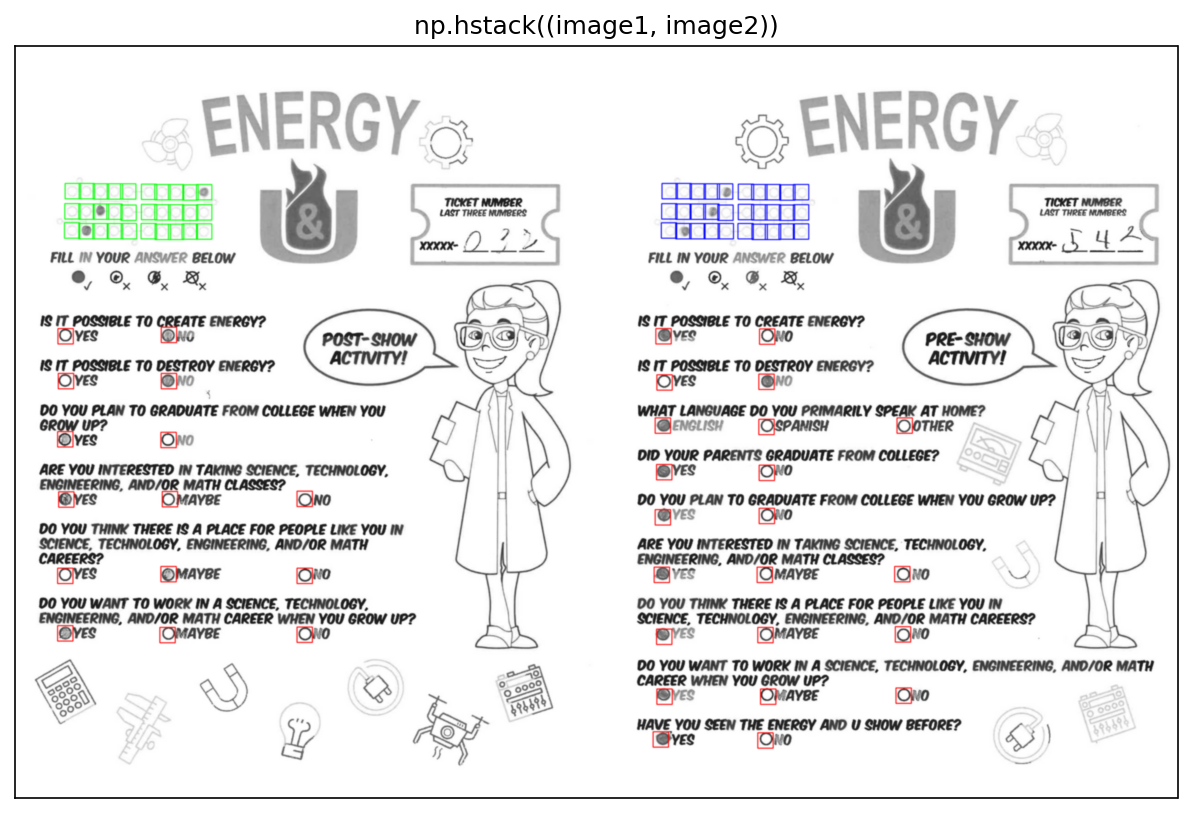

In [7]:
image1 = master['v1'].imagen_color.copy()
image2 = master['v2'].imagen_color.copy()
window_name = 'Image'
color = (255, 0, 0)
thickness = 2
ancho, alto = master['v2'].size_rect

for num, (x, y) in enumerate(master['v2'].list_option):
    cv2.rectangle(image2, (x, y), (x + ancho, y + alto), color=(0, 0, 255), thickness=2)
for num, (x, y) in enumerate(master['v1'].list_option):
    cv2.rectangle(image1, (x, y), (x + ancho, y + alto), color=(0, 0, 255), thickness=2)

for num, (x, y) in enumerate(master['v1'].number):
    cv2.rectangle(image1, (x, y), (x + ancho, y + alto), color=(0, 255, 0), thickness=2)
for num, (x, y) in enumerate(master['v2'].number):
    cv2.rectangle(image2, (x, y), (x + ancho, y + alto), color=(255, 0, 0), thickness=2)
sshow(np.hstack((image1, image2)))


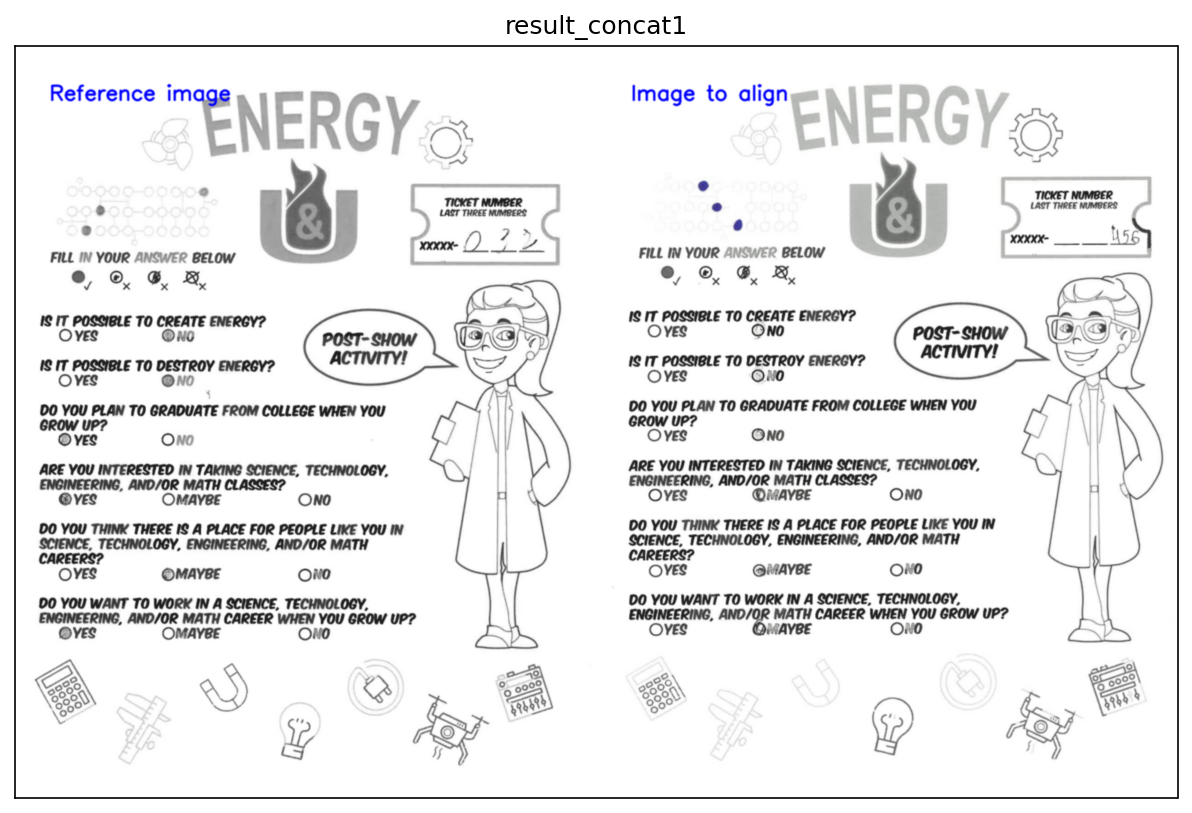

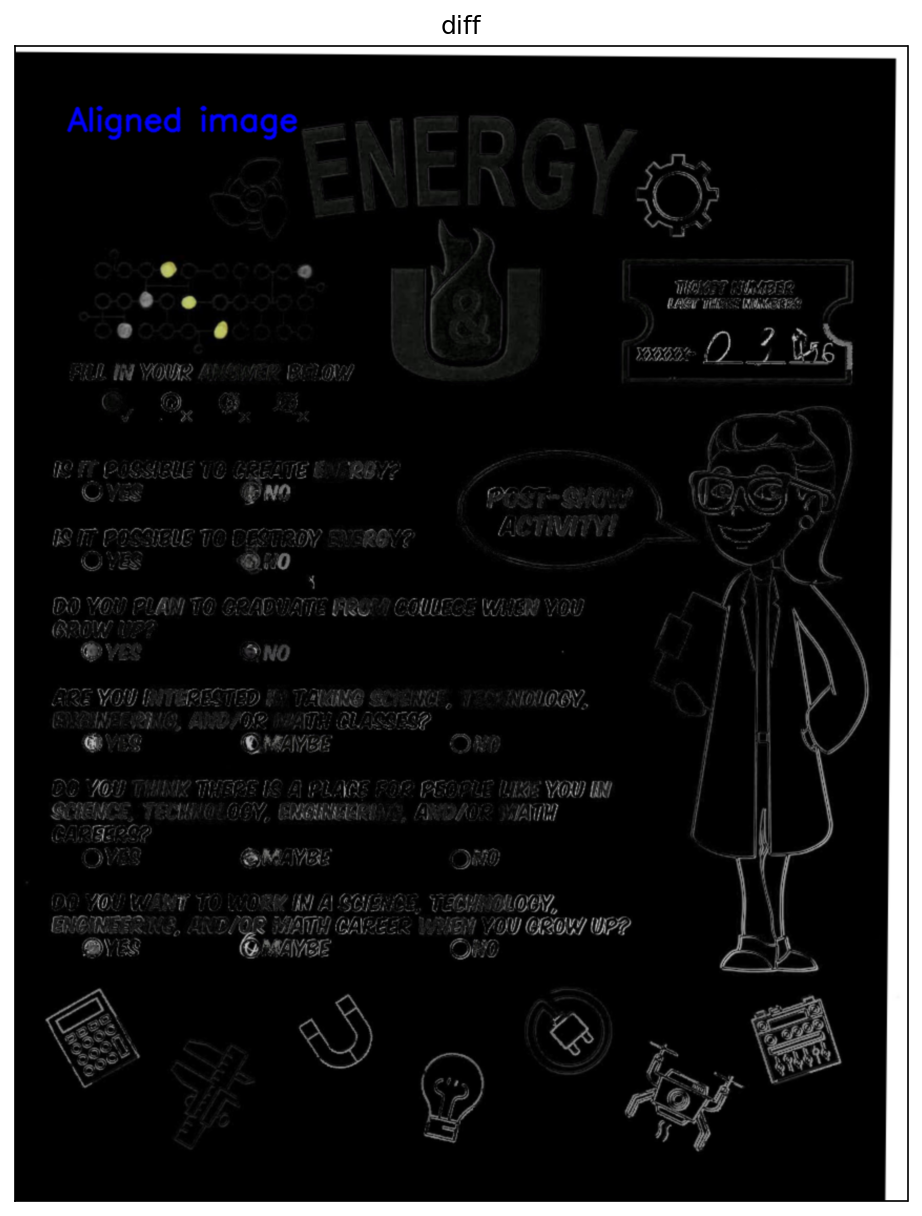

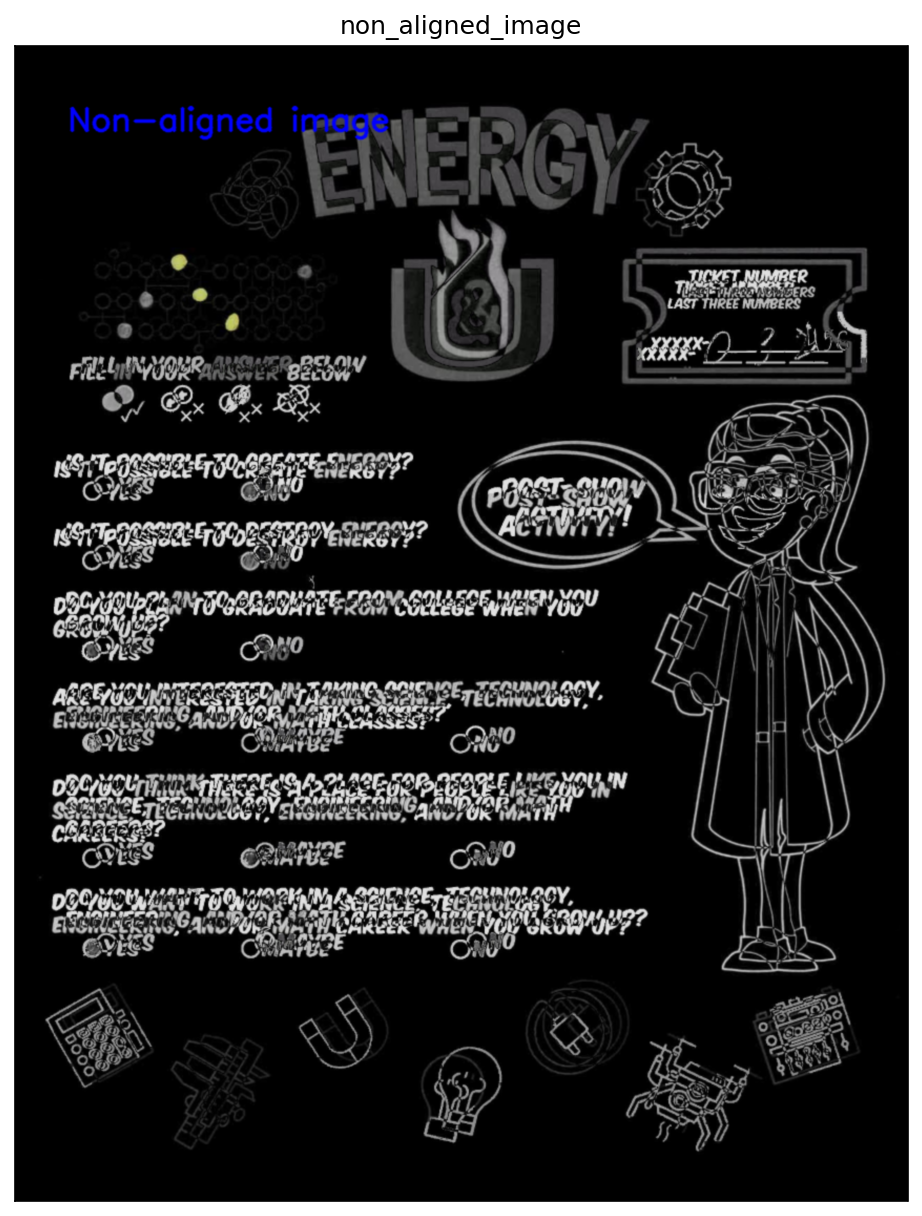

In [8]:
for file in files:
    if file.endswith(".jpg") and not file.startswith("num"):
        img_temp = ImageMaster(os.path.join(path, file))
        chi_squared = round(cv2.compareHist(master['v2'].hist, img_temp.hist, cv2.HISTCMP_CHISQR), 2)
        v = master['v2'].v if chi_squared < 500 else ("v1" if master['v2'].v == "v2" else "v2")
        img_align = align_images(master[v].imagen_color, img_temp.imagen_color)
        display_results(master[v].imagen_color, img_temp.imagen_color, img_align, 0.5)
        break

In [9]:
for file in tqdm(files):
    if file.endswith(".jpg") and not file.startswith("num"):
        img_temp = ImageMaster(os.path.join(path, file))
        chi_squared = round(cv2.compareHist(master['v2'].hist, img_temp.hist, cv2.HISTCMP_CHISQR), 2)
        v = master['v2'].v if chi_squared < 500 else ("v1" if master['v2'].v == "v2" else "v2")
        img_align = align_images(master[v].imagen_color, img_temp.imagen_color)
        img_temp.actualizar_imagen(img_align)
        img_temp.number = master[v].number.copy()
        master[v].list_of_list.append(img_temp.extraer_coordenadas_y_area(master[v]))

100%|██████████| 180/180 [00:16<00:00, 11.17it/s]


In [10]:
master["v1"].update_df()
master["v2"].update_df()
dv2 = master["v2"].df.copy()
dv1 = master["v1"].df.copy()

In [11]:
dv2 = master["v2"].df.copy()
dv1 = master["v1"].df.copy()
dv2

,file,Create_v2,Destroy_v2,Language,Parents_Graduates,Graduation_plans_v2,Interesting_scince_v2,perception_science_v2,work_science_v2,before seen,number_control
0,Progreso 4th Pre-Show w_ Errors00.jpg,0,0,0,0,0,1,0,1,1,8
1,Progreso 4th Pre-Show w_ Errors01.jpg,0,1,1,1,0,0,1,0,1,855
2,Progreso 4th Pre-Show w_ Errors02.jpg,0,1,2,1,1,2,1,1,0,86
3,Progreso 4th Pre-Show w_ Errors03.jpg,0,1,0,0,0,2,1,2,1,856
4,Progreso 4th Pre-Show00.jpg,0,1,1,0,1,0,0,1,0,8
...,...,...,...,...,...,...,...,...,...,...,...
82,Progreso 4th Pre-Show78.jpg,0,1,0,0,0,0,0,0,1,85
83,Progreso 4th Pre-Show79.jpg,0,0,1,0,0,1,0,0,1,485
84,Progreso 4th Pre-Show80.jpg,0,1,0,0,0,1,0,1,0,854
85,Progreso 4th Pre-Show81.jpg,0,0,0,0,0,1,0,2,0,8


In [12]:
dv1 = dv1.astype(str)
dv2 = dv2.astype(str)

target_columns = [master['v1'].list_columns[i] for i in [1,2,3]]
dv1.loc[:, target_columns] = dv1.loc[:, target_columns].replace({'0': 'YES', '1': 'NO'})

target_columns = [master['v1'].list_columns[i] for i in [4,5,6]]
dv1.loc[:, target_columns] = dv1.loc[:, target_columns].replace({'0': 'YES', '1': 'MAYBE', '2': 'NO'})

target_columns = [master['v2'].list_columns[i] for i in [1,2,4,5,9]] #No
dv2.loc[:, target_columns] = dv2.loc[:, target_columns].replace({'0': 'YES', '1': 'NO'})

target_columns = [master['v2'].list_columns[i] for i in [6,7,8]] #No
dv2.loc[:, target_columns] = dv2.loc[:, target_columns].replace({'0': 'YES', '1': 'MAYBE', '2': 'NO'})

target_columns = [master['v2'].list_columns[i] for i in [3]] #0 eng 1 esp 2 other
dv2.loc[:, target_columns] = dv2.loc[:, target_columns].replace({'0': 'ENG', '1': 'ESP', '2': 'OTHER'})


In [13]:
dv1

,file,create_v1,Destroy_v2,Graduation_plans_v1,Interesting_scince_v1,perception_science_v1,work_science_v1,number_control
0,Progreso 4th Post-Show w_ Errors0.jpg,NO,YES,YES,YES,YES,YES,96
1,Progreso 4th Post-Show w_ Errors1.jpg,NO,YES,YES,YES,YES,YES,9
2,Progreso 4th Post-Show w_ Errors2.jpg,NO,YES,YES,YES,YES,YES,96666666
3,Progreso 4th Post-Show w_ Errors3.jpg,NO,YES,YES,YES,YES,YES,
4,Progreso 4th Post-Show00.jpg,YES,YES,YES,YES,YES,YES,67
...,...,...,...,...,...,...,...,...
82,Progreso 4th Post-Show78.jpg,NO,YES,YES,YES,YES,YES,9
83,Progreso 4th Post-Show79.jpg,NO,YES,YES,YES,YES,YES,796
84,Progreso 4th Post-Show80.jpg,NO,YES,YES,YES,YES,YES,96866
85,Progreso 4th Post-Show81.jpg,NO,YES,YES,YES,YES,YES,7665


In [14]:
dv2

,file,Create_v2,Destroy_v2,Language,Parents_Graduates,Graduation_plans_v2,Interesting_scince_v2,perception_science_v2,work_science_v2,before seen,number_control
0,Progreso 4th Pre-Show w_ Errors00.jpg,YES,YES,ENG,YES,YES,MAYBE,YES,MAYBE,NO,8
1,Progreso 4th Pre-Show w_ Errors01.jpg,YES,NO,ESP,NO,YES,YES,MAYBE,YES,NO,855
2,Progreso 4th Pre-Show w_ Errors02.jpg,YES,NO,OTHER,NO,NO,NO,MAYBE,MAYBE,YES,86
3,Progreso 4th Pre-Show w_ Errors03.jpg,YES,NO,ENG,YES,YES,NO,MAYBE,NO,NO,856
4,Progreso 4th Pre-Show00.jpg,YES,NO,ESP,YES,NO,YES,YES,MAYBE,YES,8
...,...,...,...,...,...,...,...,...,...,...,...
82,Progreso 4th Pre-Show78.jpg,YES,NO,ENG,YES,YES,YES,YES,YES,NO,85
83,Progreso 4th Pre-Show79.jpg,YES,YES,ESP,YES,YES,MAYBE,YES,YES,NO,485
84,Progreso 4th Pre-Show80.jpg,YES,NO,ENG,YES,YES,MAYBE,YES,MAYBE,YES,854
85,Progreso 4th Pre-Show81.jpg,YES,YES,ENG,YES,YES,MAYBE,YES,NO,YES,8
